<a href="https://colab.research.google.com/github/Dan-KM/BI_2_Assignments/blob/feature%2Finit_eda/regression/regression_assignment_A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Real Estate dataset**

The goal is to predict the montly rent based on some features given in the dataset.

##**Installing dependencies and getting the environment ready**

In [2]:
import sys
import subprocess

#   Setting ENV_SETUP to "COLAB"  by default because it it where we are going to
#   be running our code

ENV_SETUP= "COLAB"

In [3]:
def silent_pip_install(args):
    """
    Used to run a command quietly and
    only shows an error if something went wrong.
    :param args: Array of arguments that form the command.
    :return:
    """

    # `sys.executable` is added to ensure you are installing into the virtual environment
    cmd = [sys.executable, "-m", "pip", *args]
    # `subprocess.run` is used to execute an external command
    # `stdout=subprocess.PIPE` captures normal output into result.stdout
    # `stderr=subprocess.PIPE` captures error output into result.stderr
    # `text=True` decodes output as strings (str) instead of bytes, so you can print/read it directly.
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    # `result.returncode` is the process exit status. 0 means success.
    if result.returncode != 0:
        print(result.stderr)

if ENV_SETUP == "PROD":
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/prod.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"STAGING"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/dev.txt",
        "-c", "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/constraints.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"TESTING"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/dev.txt",
        "-c", "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/constraints.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"COLAB"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/colab.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

elif ENV_SETUP in {"DEV"}:
    silent_pip_install([
        "install", "-r",
        "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/dev.txt",
        "-c", "https://raw.githubusercontent.com/course-files/RegressionAndClassification/refs/heads/main/requirements/constraints.txt"
    ])
    print(f"Completed installation of environment dependencies for '{ENV_SETUP}'.")

Completed installation of environment dependencies for 'COLAB'.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 85
np.random.seed(RANDOM_STATE)

# For suppressing warnings displayed in the notebook
import warnings
warnings.filterwarnings('ignore')

print("The environment is ready.")

The environment is ready.


### **Uploading data**

From [GitHub](https://github.com/course-files/RegressionAndClassification/blob/main/data/real_estate_rental_price.csv)

In [10]:
import urllib.request
import os
import pandas as pd

dataset_path = './data/real_estate_rental_price.csv'

url = 'https://raw.githubusercontent.com/course-files/RegressionAndClassification/main/data/real_estate_rental_price.csv'

# Delete if there is an existing file
if os.path.exists(dataset_path):
    os.remove(dataset_path)

# Create data directory
os.makedirs('./data', exist_ok=True)

# Download correct CSV
print("Downloading dataset...")
urllib.request.urlretrieve(url, dataset_path)
print("✅ Dataset downloaded")

# Load data
use_cols = [
    'property_id',
    'property_type',
    'neighborhood',
    'furnishing_status',
    'property_age_years',
    'size_sqm',
    'num_bedrooms',
    'num_bathrooms',
    'distance_to_cbd_km',
    'service_charge_kes',
    'garage_size_sqm',
    'security_rating',
    'amenities_score',
    'nearby_schools_count',
    'monthly_rent_kes'
]

real_estate_data = pd.read_csv(
    dataset_path,
    usecols=use_cols,
    encoding='utf-8'
)

print("This dataset has ", real_estate_data.shape[1], " rows and ",real_estate_data.shape[0], " columns")
real_estate_data.head()

✅ Dataset downloaded
This dataset has  15  rows and  900  columns


,property_id,property_type,neighborhood,furnishing_status,property_age_years,size_sqm,num_bedrooms,num_bathrooms,distance_to_cbd_km,service_charge_kes,garage_size_sqm,security_rating,amenities_score,nearby_schools_count,monthly_rent_kes
0,1,Townhouse,Kilimani,Unfurnished,5.5,78.3,3,3,20.9,14590.0,10.0,3.0,33.2,5,119264.0
1,2,Apartment,Ngong Road,Fully Furnished,7.3,152.2,5,5,8.0,36488.0,NaN,3.0,29.9,1,139812.0
2,3,Maisonette,Ngong Road,Unfurnished,6.2,60.2,2,2,21.7,15566.0,12.6,NaN,45.9,1,29930.0
3,4,Bungalow,Kilimani,Unfurnished,2.6,141.1,5,4,35.4,29692.0,22.6,3.0,10.6,1,140880.0
4,5,Apartment,Kilimani,Unfurnished,2.6,136.8,4,2,5.6,23097.0,NaN,2.0,45.0,3,135241.0


### **Identify target**

In our case, the tarket is monthly rent

In [6]:
TARGET = "monthly_rent_kes"

## **Initial EDA**

#### General

In [31]:
real_estate_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_id           900 non-null    int64  
 1   property_type         900 non-null    object 
 2   neighborhood          900 non-null    object 
 3   furnishing_status     900 non-null    object 
 4   property_age_years    900 non-null    float64
 5   size_sqm              900 non-null    float64
 6   num_bedrooms          900 non-null    int64  
 7   num_bathrooms         900 non-null    int64  
 8   distance_to_cbd_km    900 non-null    float64
 9   service_charge_kes    900 non-null    float64
 10  garage_size_sqm       388 non-null    float64
 11  security_rating       842 non-null    float64
 12  amenities_score       900 non-null    float64
 13  nearby_schools_count  900 non-null    int64  
 14  monthly_rent_kes      900 non-null    float64
 15  is_outlier            9

We don't have empty cells

In [32]:
numeric_cols = real_estate_data.select_dtypes(include=[np.number]).columns.drop("property_id")
categorical_cols = real_estate_data.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

print("\nThe identified numeric columns (measures) are:")
print(numeric_cols.tolist())

print("\nThe identified categorical columns (dimensions) are:")
print(categorical_cols.tolist())

q1 = real_estate_data[numeric_cols].quantile(0.25)
q2 = real_estate_data[numeric_cols].quantile(0.50)
q3 = real_estate_data[numeric_cols].quantile(0.75)

iqr = q3 - q1

distribution_summary = pd.DataFrame({
    "min": real_estate_data[numeric_cols].min(),
    "q1_25%": q1,
    "q2_50%": q2,
    "q3_75%": q3,
    "max": real_estate_data[numeric_cols].max(),
    "mean": real_estate_data[numeric_cols].mean(),
    "mode": real_estate_data[numeric_cols].mode().iloc[0],
    "variance": real_estate_data[numeric_cols].var(),
    "std_dev": real_estate_data[numeric_cols].std(),
    "skewness": real_estate_data[numeric_cols].skew(),
    "kurtosis": real_estate_data[numeric_cols].kurt(),
    "IQR": iqr,
    "lower_fence": q1 - 1.5 * iqr,
    "upper_fence": q3 + 1.5 * iqr,
})

distribution_summary.round(2).style.format("{:,.2f}")


The identified numeric columns (measures) are:
['property_age_years', 'size_sqm', 'num_bedrooms', 'num_bathrooms', 'distance_to_cbd_km', 'service_charge_kes', 'garage_size_sqm', 'security_rating', 'amenities_score', 'nearby_schools_count', 'monthly_rent_kes']

The identified categorical columns (dimensions) are:
['property_type', 'neighborhood', 'furnishing_status', 'is_outlier']


,min,q1_25%,q2_50%,q3_75%,max,mean,mode,variance,std_dev,skewness,kurtosis,IQR,lower_fence,upper_fence
property_age_years,0.20,3.50,5.95,9.30,31.50,6.98,3.30,23.04,4.80,1.29,2.21,5.80,-5.20,18.00
size_sqm,22.00,63.28,86.25,107.88,217.90,86.61,22.00,"1,120.71",33.48,0.23,-0.07,44.60,-3.63,174.78
num_bedrooms,0.00,2.00,3.00,4.00,6.00,2.71,3.00,1.56,1.25,0.13,-0.23,2.00,-1.00,7.00
num_bathrooms,1.00,2.00,2.00,3.00,5.00,2.41,2.00,0.96,0.98,0.22,-0.60,1.00,0.50,4.50
distance_to_cbd_km,0.50,4.60,7.40,11.60,45.00,8.77,4.70,35.80,5.98,1.53,3.64,7.00,-5.90,22.10
service_charge_kes,"1,000.00","10,487.00","15,098.00","19,847.25","49,032.00","15,550.76","8,292.00","48,081,198.58","6,934.06",0.60,0.80,"9,360.25","-3,553.38","33,887.62"
garage_size_sqm,0.00,11.28,15.70,19.30,32.40,15.40,12.90,36.97,6.08,-0.05,-0.12,8.02,-0.76,31.34
security_rating,1.00,3.00,4.00,4.00,5.00,3.54,4.00,0.87,0.93,-0.20,-0.45,1.00,1.50,5.50
amenities_score,0.00,39.20,54.15,70.80,100.00,54.60,100.00,471.12,21.71,-0.02,-0.49,31.60,-8.20,118.20
nearby_schools_count,0.00,1.00,2.00,3.00,9.00,2.22,2.00,2.20,1.48,0.67,0.41,2.00,-2.00,6.00


From this EDA, we can notice a few things:

Concerning skewness, most values are okay except property_age_years, distance_to_cbd_km, and montly_rent_kes which are considered to be strongly skewed because their skewness is outside ] -1.0 , 1.0 [


#### Identify outliers

In [12]:
# Identify values below the lower fence or above the upper fence
# These are statistically considered as outliers
outlier_mask = (
    (real_estate_data[numeric_cols] < q1 - 1.5 * iqr) |
    (real_estate_data[numeric_cols] > q3 + 1.5 * iqr)
)

# Record features that contain at least one potential outlier
# Check each row (axis=1): True if the row contains an outlier in any numeric
# column
outliers = real_estate_data[outlier_mask.any(axis=1)]

outlier_counts = outlier_mask.sum().rename("outlier_count").to_frame()

outlier_counts

,outlier_count
property_age_years,30
size_sqm,4
num_bedrooms,0
num_bathrooms,12
distance_to_cbd_km,35
service_charge_kes,11
garage_size_sqm,1
security_rating,10
amenities_score,0
nearby_schools_count,5


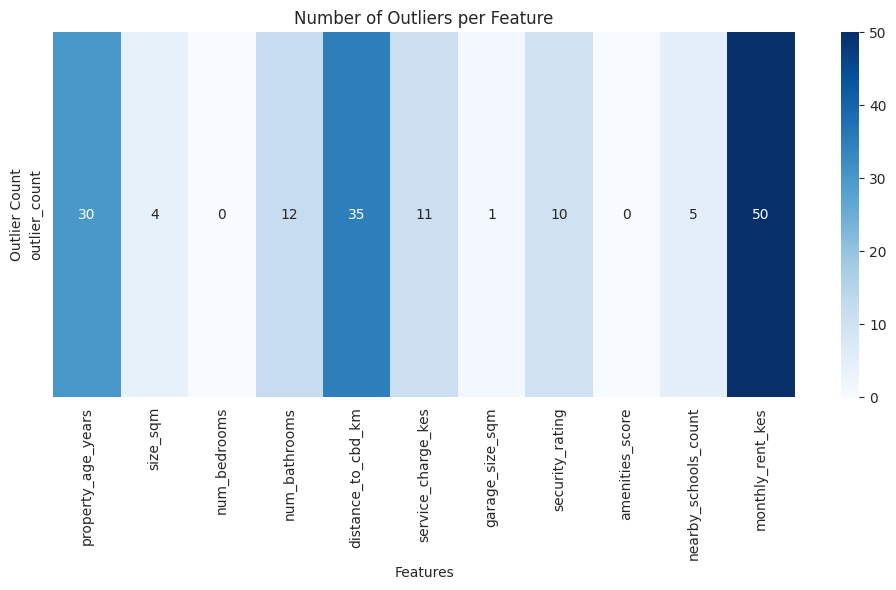

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(outlier_counts.T, annot=True, cmap='Blues', fmt='d')
plt.title('Number of Outliers per Feature')
plt.xlabel('Features')
plt.ylabel('Outlier Count')
plt.tight_layout()
plt.show()

#### Measures of Relationships

We will use Pearson and Pearman correlation to capture possible linear relationships between fields of this dataset

In [21]:
# Pearson correlation captures linear relationships; Spearman captures monotonic,
# possibly non-linear relationships. Comparing the two flags non-linear predictors.
pearson_corr = real_estate_data[numeric_cols].corr(method="pearson")[TARGET].drop(TARGET).sort_values(ascending=False)
spearman_corr = real_estate_data[numeric_cols].corr(method="spearman")[TARGET].drop(TARGET).sort_values(ascending=False)

relationship_summary = pd.DataFrame({"Pearson": pearson_corr, "Spearman": spearman_corr})
relationship_summary["gap"] = (relationship_summary["Spearman"] - relationship_summary["Pearson"]).abs()
relationship_summary.sort_values("gap", ascending=False).round(3)

,Pearson,Spearman,gap
num_bedrooms,0.700,0.796,0.096
size_sqm,0.702,0.785,0.083
num_bathrooms,0.606,0.670,0.064
service_charge_kes,0.641,0.693,0.052
garage_size_sqm,-0.045,-0.004,0.042
security_rating,0.005,-0.009,0.014
distance_to_cbd_km,-0.115,-0.126,0.011
amenities_score,0.077,0.088,0.010
nearby_schools_count,0.078,0.081,0.003
property_age_years,-0.072,-0.075,0.003


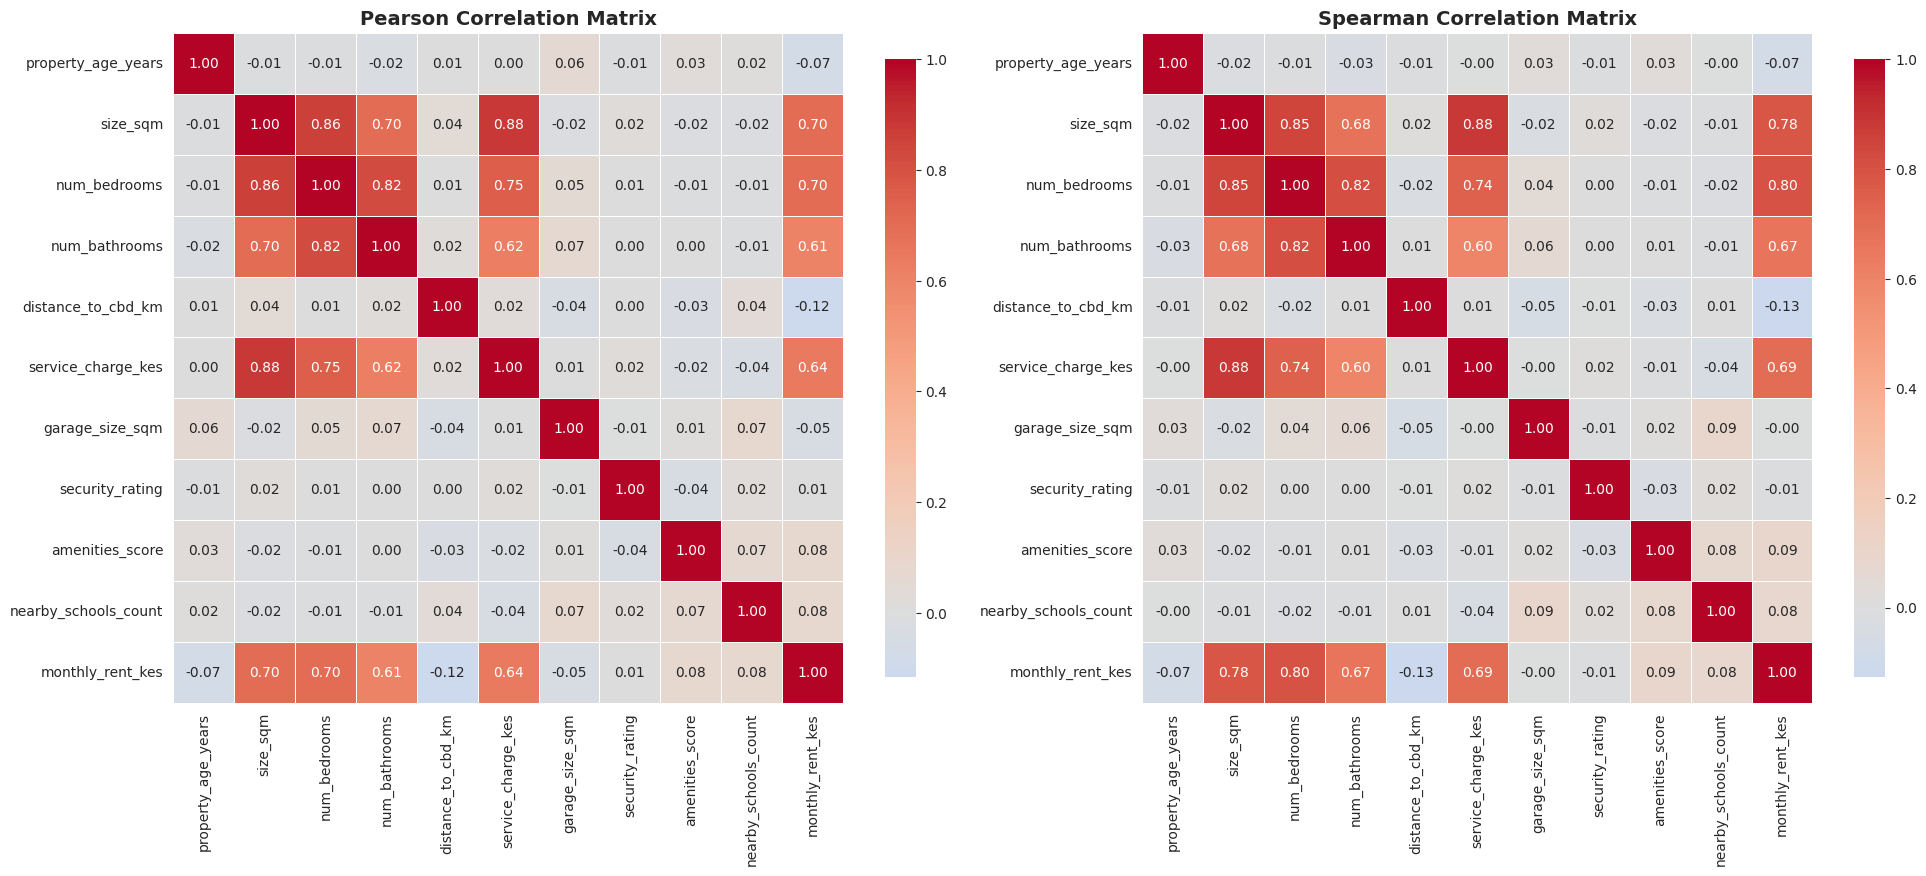

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# Pearson Correlation
corr_pearson = real_estate_data[numeric_cols].corr(method="pearson")
sns.heatmap(corr_pearson,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            ax=ax1)
ax1.set_title("Pearson Correlation Matrix", fontsize=14, fontweight='bold')

# Spearman Correlation
corr_spearman = real_estate_data[numeric_cols].corr(method="spearman")
sns.heatmap(corr_spearman,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            ax=ax2)
ax2.set_title("Spearman Correlation Matrix", fontsize=14, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.show()

The results of both methods are close to similar

#### Basic Visualization

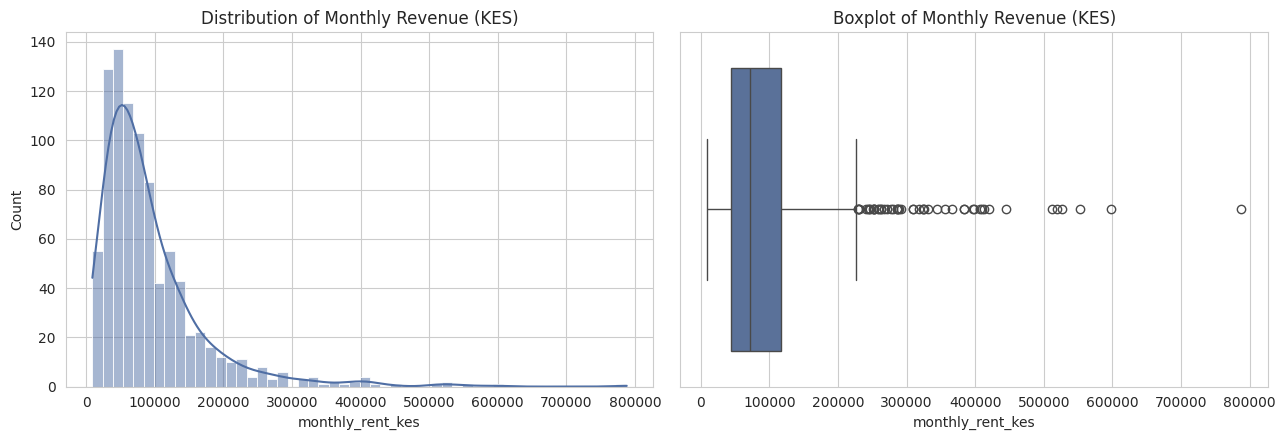

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(real_estate_data[TARGET], kde=True, ax=axes[0], color="#4F6EA4")
axes[0].set_title("Distribution of Monthly Revenue (KES)")

sns.boxplot(x=real_estate_data[TARGET], ax=axes[1], color="#4F6EA4")
axes[1].set_title("Boxplot of Monthly Revenue (KES)")

plt.tight_layout()
plt.show()

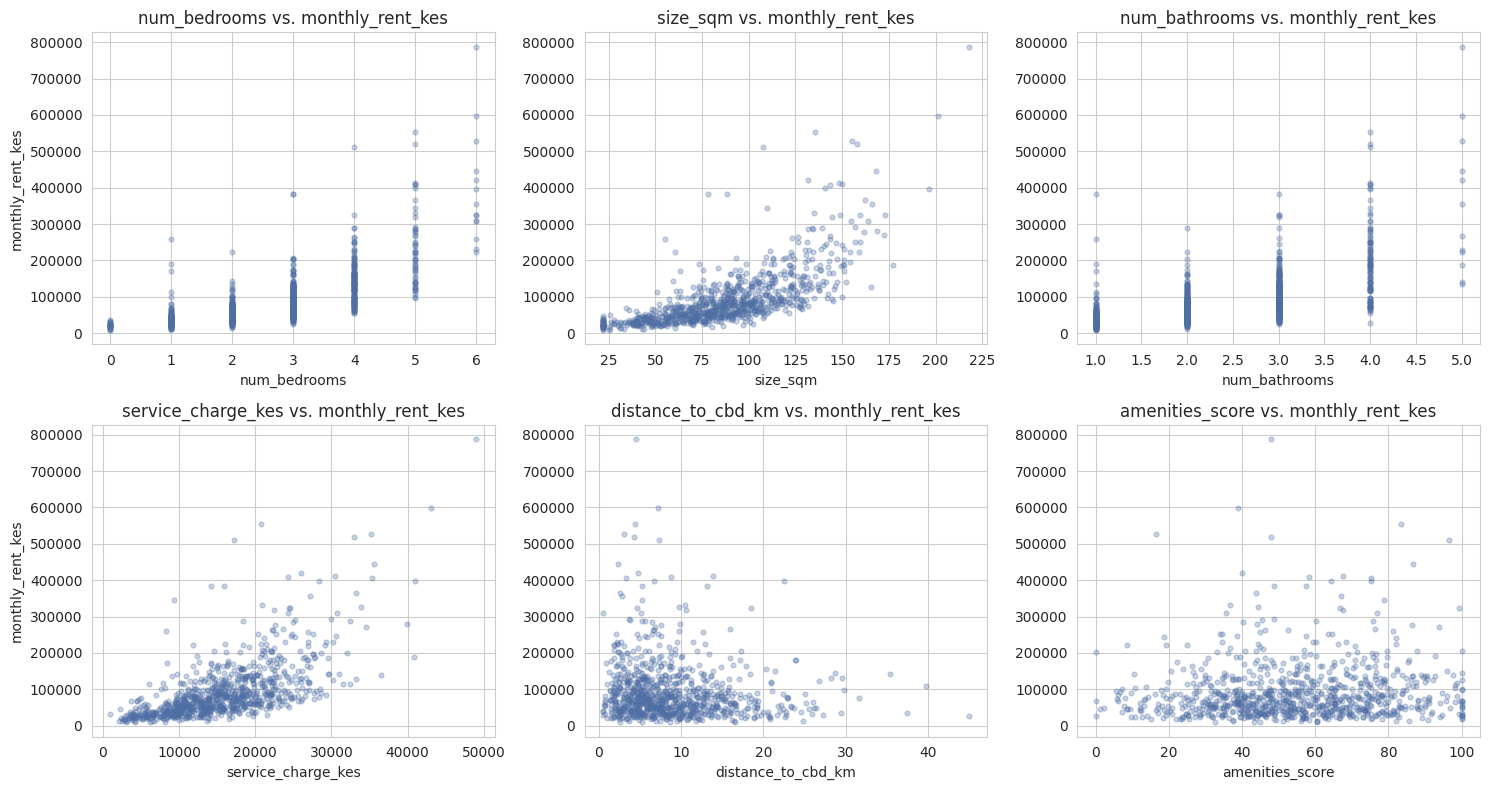

In [25]:


key_predictors = ["num_bedrooms", "size_sqm", "num_bathrooms", "service_charge_kes", "distance_to_cbd_km", "amenities_score"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# axes is a 2D *array* of subplot slots (from plt.subplots(2, 3, ...))
# `axes.flatten()` turns it into a 1D *list* of axes: [ax1, ax2, ..., ax6].
# `zip(axes.flatten(), key_predictors)` pairs them one-by-one.
# So each loop gives:
#   ax = one subplot to draw on
#   col = one feature name to plot on that subplot

# It therefore maps each predictor to one subplot automatically.

for ax, col in zip(axes.flatten(), key_predictors):
    ax.scatter(real_estate_data[col], real_estate_data[TARGET], alpha=0.3, s=12, color="#4F6EA4")
    ax.set_xlabel(col)
    # ax.set_ylabel(TARGET if col == key_predictors[0] else "")
    ax.set_ylabel(TARGET if col in (key_predictors[0], key_predictors[3]) else "")
    ax.set_title(f"{col} vs. {TARGET}")

plt.tight_layout()
plt.show()

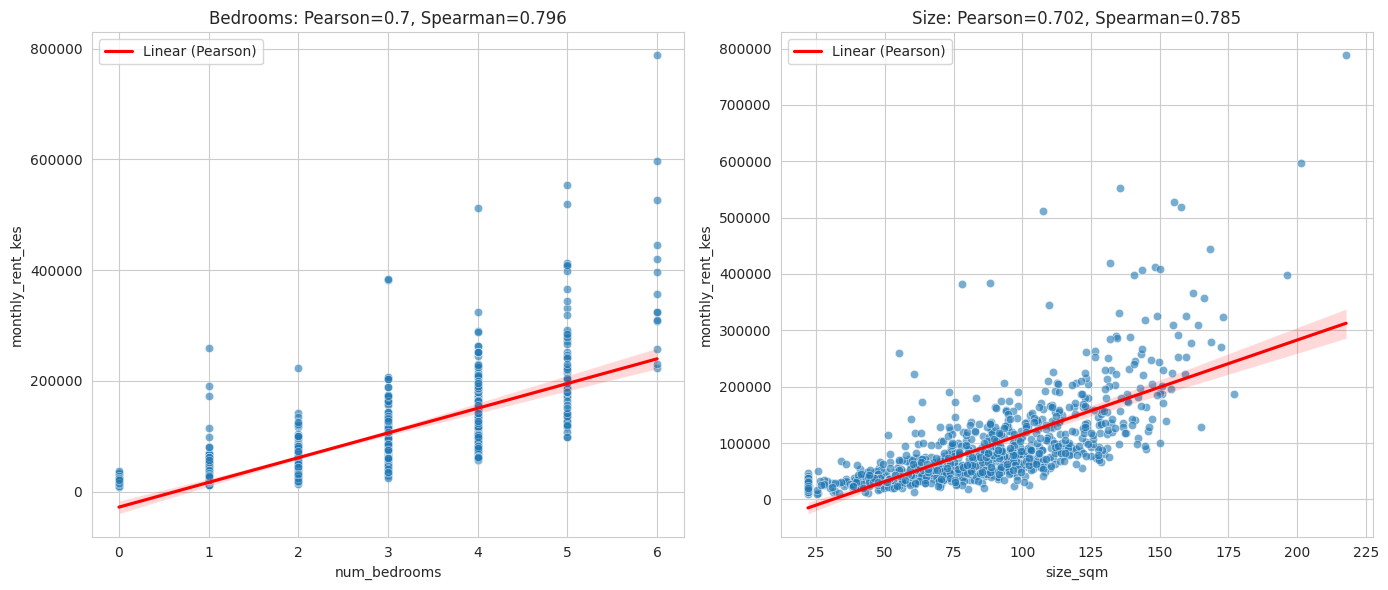

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create comparison bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Feature 1: Bedrooms
sns.scatterplot(data=real_estate_data, x='num_bedrooms', y='monthly_rent_kes', ax=ax1, alpha=0.6)
sns.regplot(data=real_estate_data, x='num_bedrooms', y='monthly_rent_kes', ax=ax1,
            scatter=False, color='red', label='Linear (Pearson)')
ax1.set_title(f'Bedrooms: Pearson={0.700}, Spearman={0.796}')
ax1.legend()

# Feature 2: Size
sns.scatterplot(data=real_estate_data, x='size_sqm', y='monthly_rent_kes', ax=ax2, alpha=0.6)
sns.regplot(data=real_estate_data, x='size_sqm', y='monthly_rent_kes', ax=ax2,
            scatter=False, color='red', label='Linear (Pearson)')
ax2.set_title(f'Size: Pearson={0.702}, Spearman={0.785}')
ax2.legend()

plt.tight_layout()
plt.show()

## **Feature selection**